In [12]:
import os
import torch
import sys
import matplotlib.pyplot as plt
from gsplat import rasterization
from optical.surface import WaterSurface
from optical.utils.test_utils import LoadDataset
from optical.utils.test_utils import combert_into_colormap, compare_rasterization_variants, np_rgb_render

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
Dataset = LoadDataset()
Dataset.set_iamge(80)

means, scales, quats, opacities, colors = Dataset.get_model_param()
pixels_wo, pixels_w, camtoworld, worldtocam, cam_center, K, height, width, image_id = Dataset.get_camera_param()

Loading 3D point cloud from: /home/taiki/dataset/river2/wo_refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/wo_refraction.
Loading 3D point cloud from: /home/taiki/dataset/river2/refraction/points3d.ply
[Parser] Loaded 100 images from /home/taiki/dataset/river2/refraction.


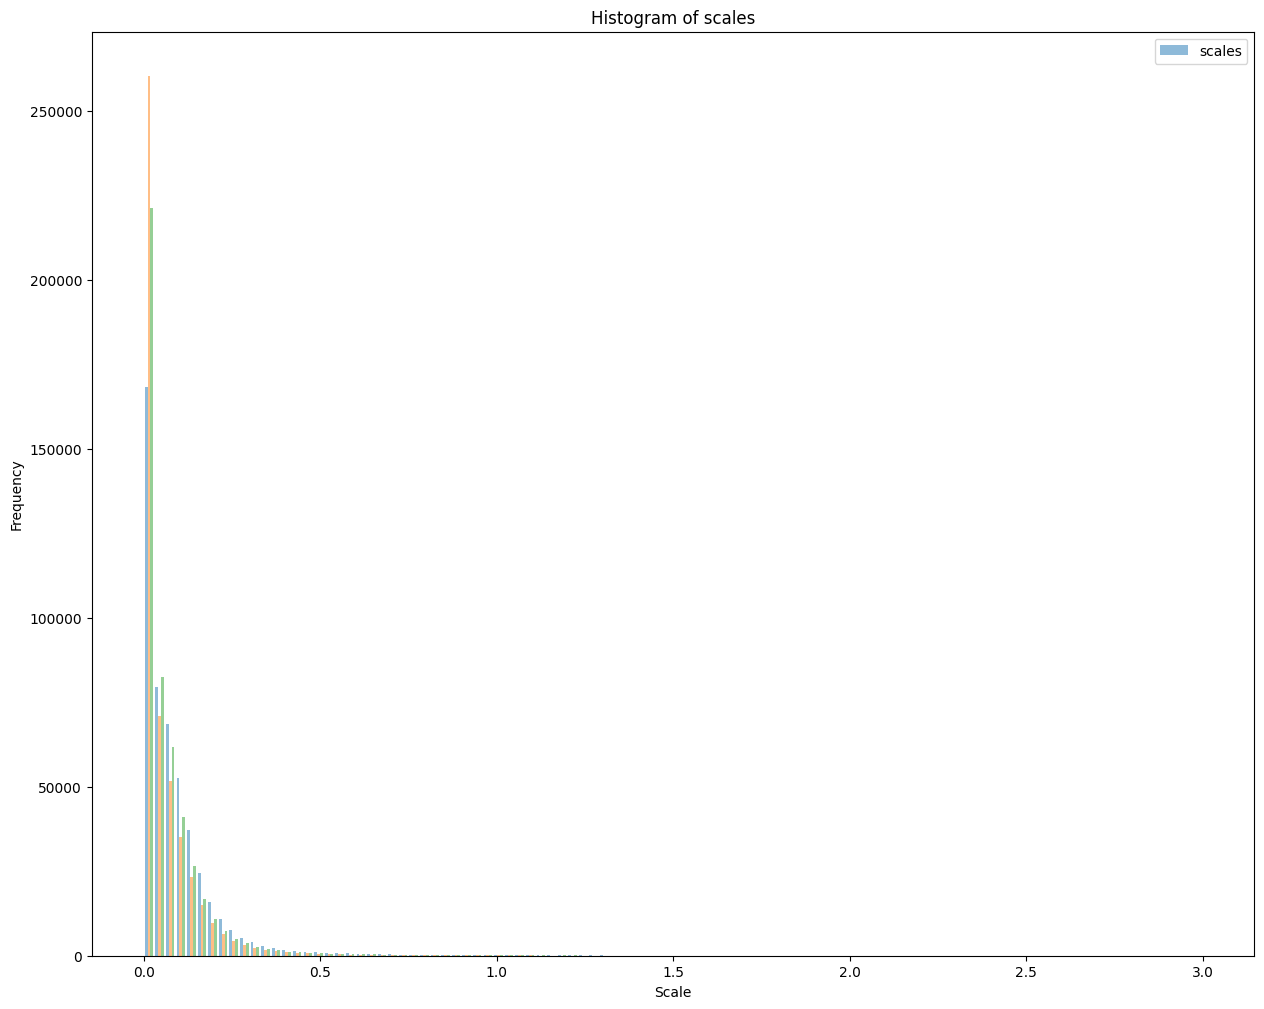

In [14]:
# show histogram of scales
plt.figure()
plt.hist(scales.detach().cpu().numpy().clip(max=3), bins=100, alpha=0.5, label='scales')
plt.xlabel('Scale')
plt.ylabel('Frequency')
plt.title('Histogram of scales')
plt.legend()
plt.show()

↑ マイナスにならないのがおかしい。
scales は、実数値で読み出されている

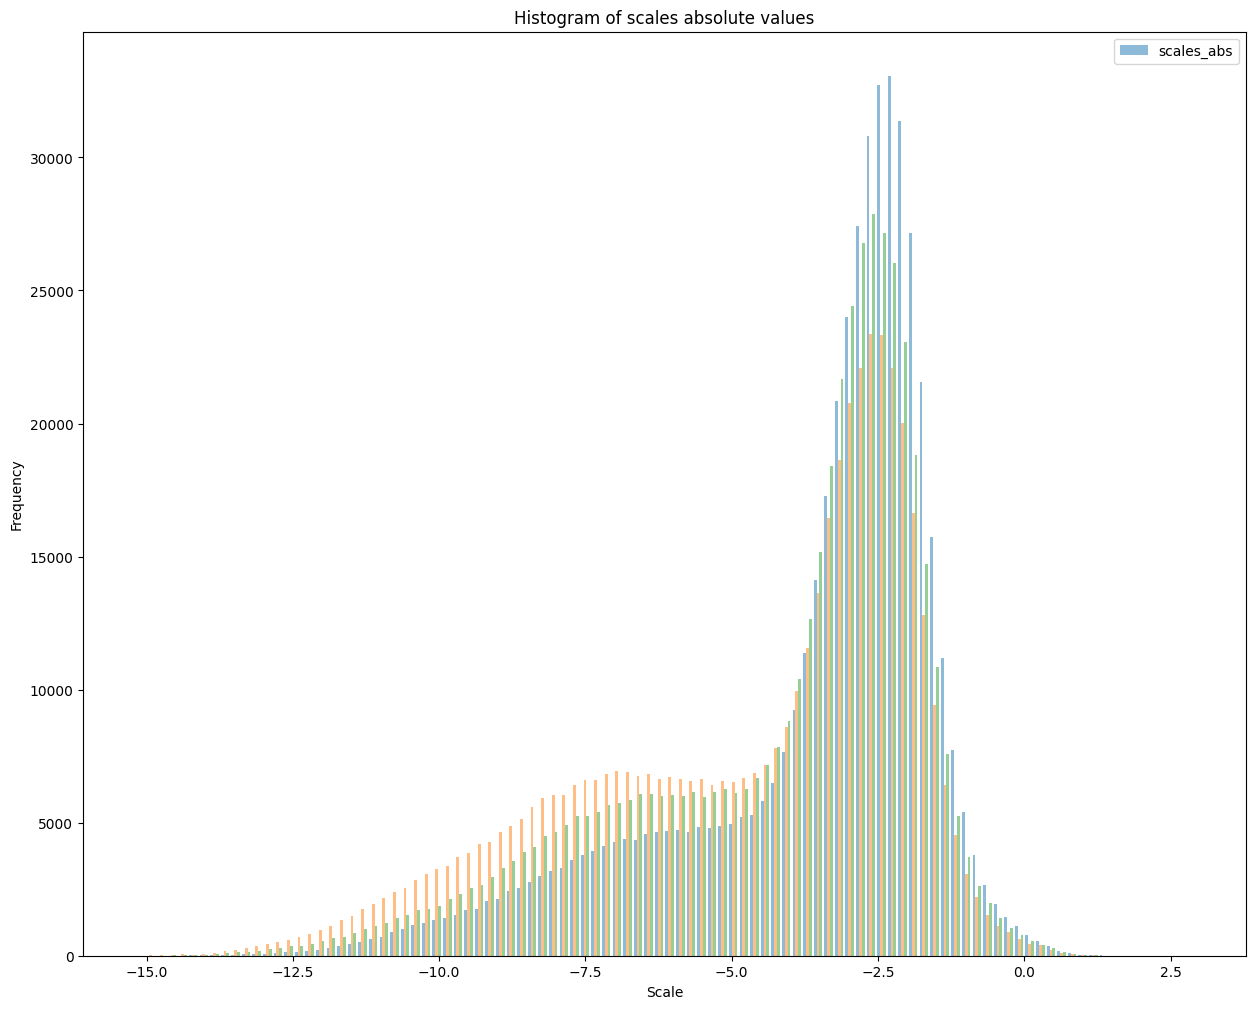

In [15]:
# show histogram of scales absolute values
plt.figure()
plt.hist(torch.log(scales).detach().cpu().numpy().clip(max=3), bins=100, alpha=0.5, label='scales_abs')
plt.xlabel('Scale')
plt.ylabel('Frequency')
plt.title('Histogram of scales absolute values')
plt.legend()
plt.show()

In [16]:
# Setting Refraction Parameters
n = 1.33
plane = 0.0
num_newton_iters = 10
newton_atol = 1e-6

WS = WaterSurface(
    means=means,
    quats=quats,
    scales=scales,
    cam_center=cam_center,
    n=n,
    plane=plane,
    flag_solve_quartic_by_newton=True,
)

jacobian = WS.dPa_dP()
t_means = WS.transform_to_appearance_position()
t_scales_by_volume = WS.scale_correction_as_real(comp_by='volume')
t_quats = WS.calc_apparent_quaternion()

map_colors = combert_into_colormap(WS.scale_correction_factor_by_volume, colormap='plasma')

tensor([-1.1309, -1.2080, -1.1221,  ..., -0.0406, -0.0441,  0.0034],
       device='cuda:0', grad_fn=<Atan2Backward0>)


/home/taiki/try-papers/gsplat/optical/surface.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.n = torch.tensor(n, dtype=torch.float32, device=device, requires_grad=False)
/home/taiki/try-papers/gsplat/optical/surface.py:80: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.plane = torch.tensor(plane, dtype=torch.float32, device=device, requires_grad=False)


In [17]:
print(colors.shape)
print(map_colors.shape)

print(torch.log(WS.scale_correction_factor_by_volume).unsqueeze(-1)) 
print(WS.volume_compression_ratio)

scales_log = WS.scales
t_scales_log = t_scales_by_volume

scales_log = torch.log(scales_log)
t_scales_log = torch.log(t_scales_log)

volume_compression_ratio = WS.volume_compression_ratio
scale_correction_factor = WS.scale_correction_factor_by_volume

torch.Size([493170, 1, 3])
torch.Size([493170, 1, 3])
tensor([[-0.5791],
        [-0.6535],
        [-0.7371],
        ...,
        [-0.6231],
        [-0.5979],
        [-1.1995]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
tensor([0.1760, 0.1408, 0.1095,  ..., 0.1542, 0.1664, 0.0274], device='cuda:0',
       grad_fn=<AbsBackward0>)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1169591].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4699299].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0364773].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.463337].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.035656].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4001914].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3938662].


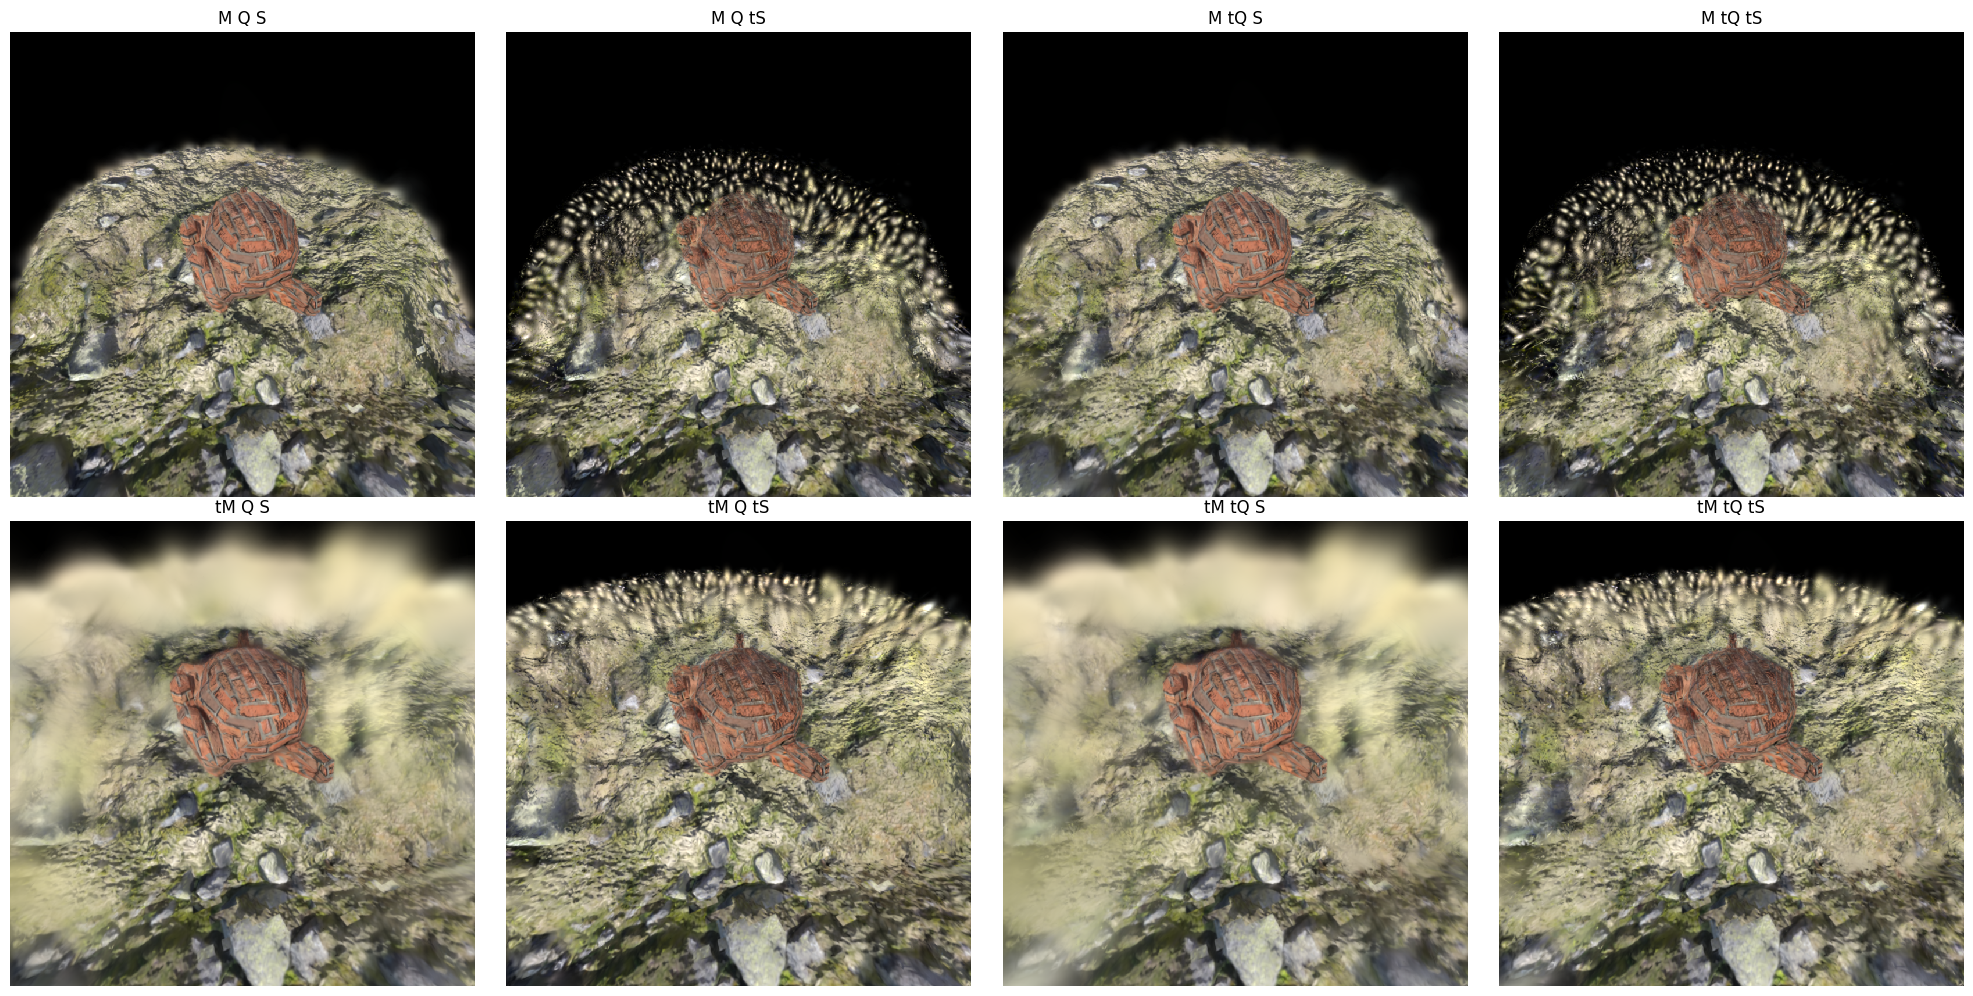

In [18]:
base_data = {
    "means": means,
    "quats": quats,
    "scales": scales,
}
transformed_data = {
    "means": t_means,
    "quats": t_quats,
    "scales": t_scales_by_volume,
}


compare_rasterization_variants(
    base_data=base_data,
    transformed_data=transformed_data,
    opacities=opacities,
    # colors=map_colors,
    colors=colors,
    worldtocam=worldtocam,
    Ks=K,
    width=width,
    height=height
)

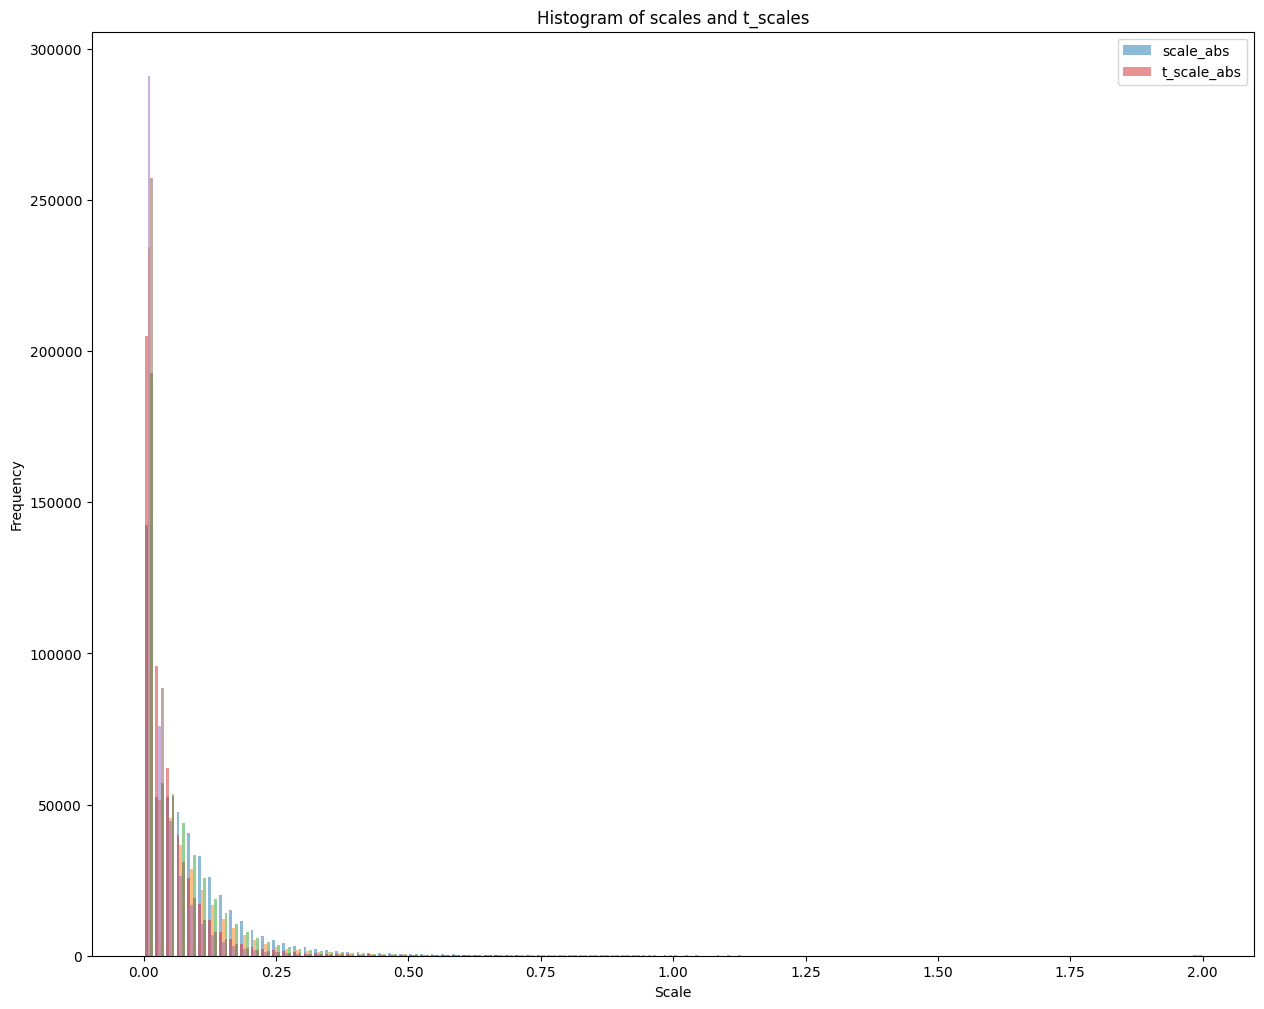

In [19]:
# show histogram of scale 
plt.figure()
plt.hist(scales.detach().cpu().numpy().clip(max=2), bins=100, alpha=0.5, label='scale_abs')
plt.hist(t_scales_by_volume.detach().cpu().numpy().clip(max=2), bins=100, alpha=0.5, label='t_scale_abs')
plt.xlabel('Scale')
plt.ylabel('Frequency')
plt.title('Histogram of scales and t_scales')
plt.legend()

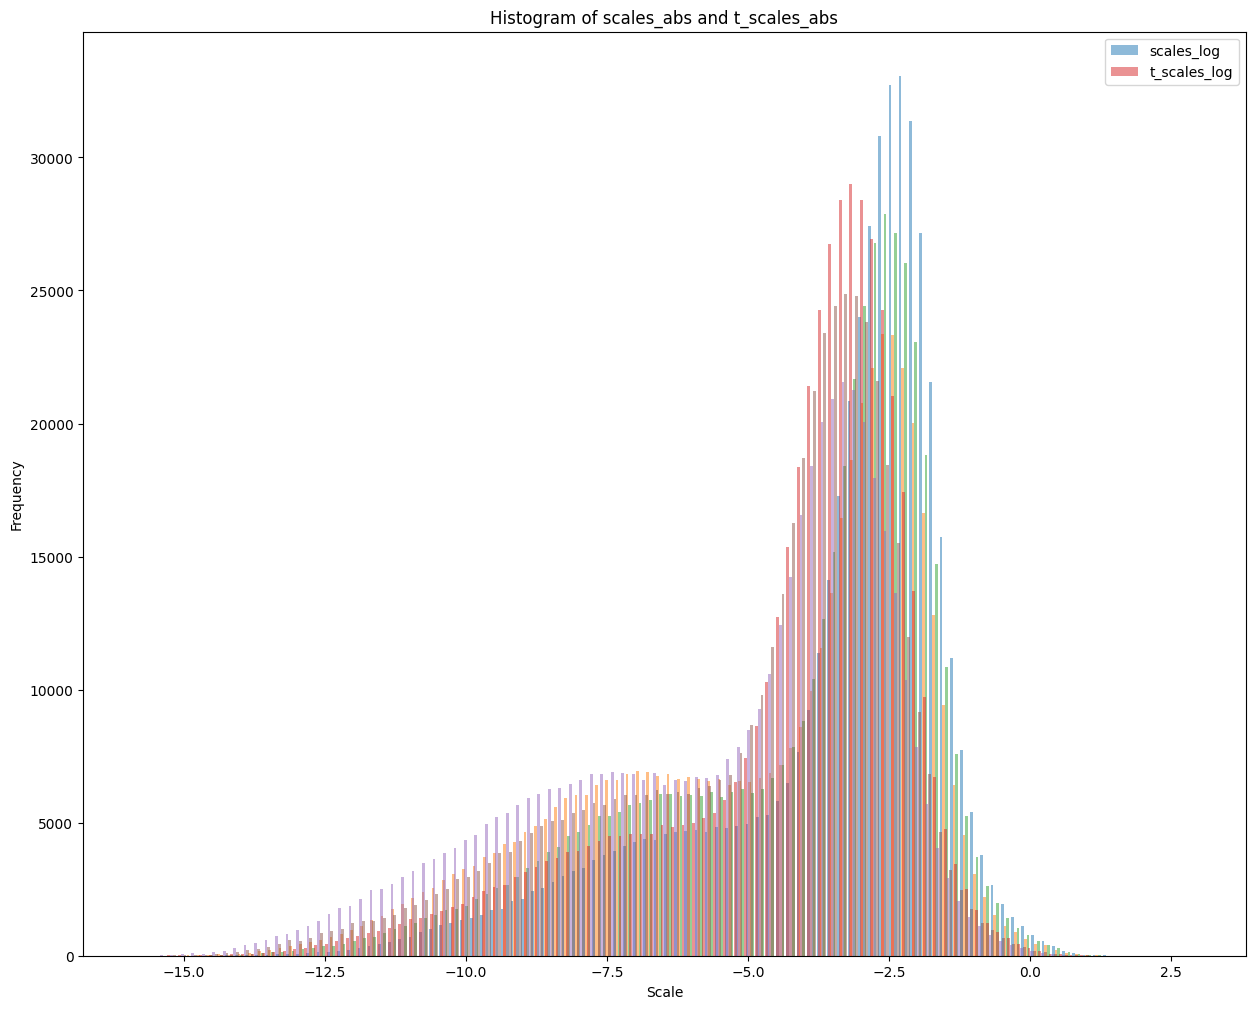

In [20]:
# show histogram of scales_abs
plt.figure()
plt.hist(scales_log.detach().cpu().numpy().clip(max=10), bins=100, alpha=0.5, label='scales_log')
plt.hist(t_scales_log.detach().cpu().numpy().clip(max=10), bins=100, alpha=0.5, label='t_scales_log')
plt.xlabel('Scale')
plt.ylabel('Frequency')
plt.title('Histogram of scales_abs and t_scales_abs')
plt.legend()
plt.show()




Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1169591].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3689427].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0364773].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3647715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.035656].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3804582].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.379169].


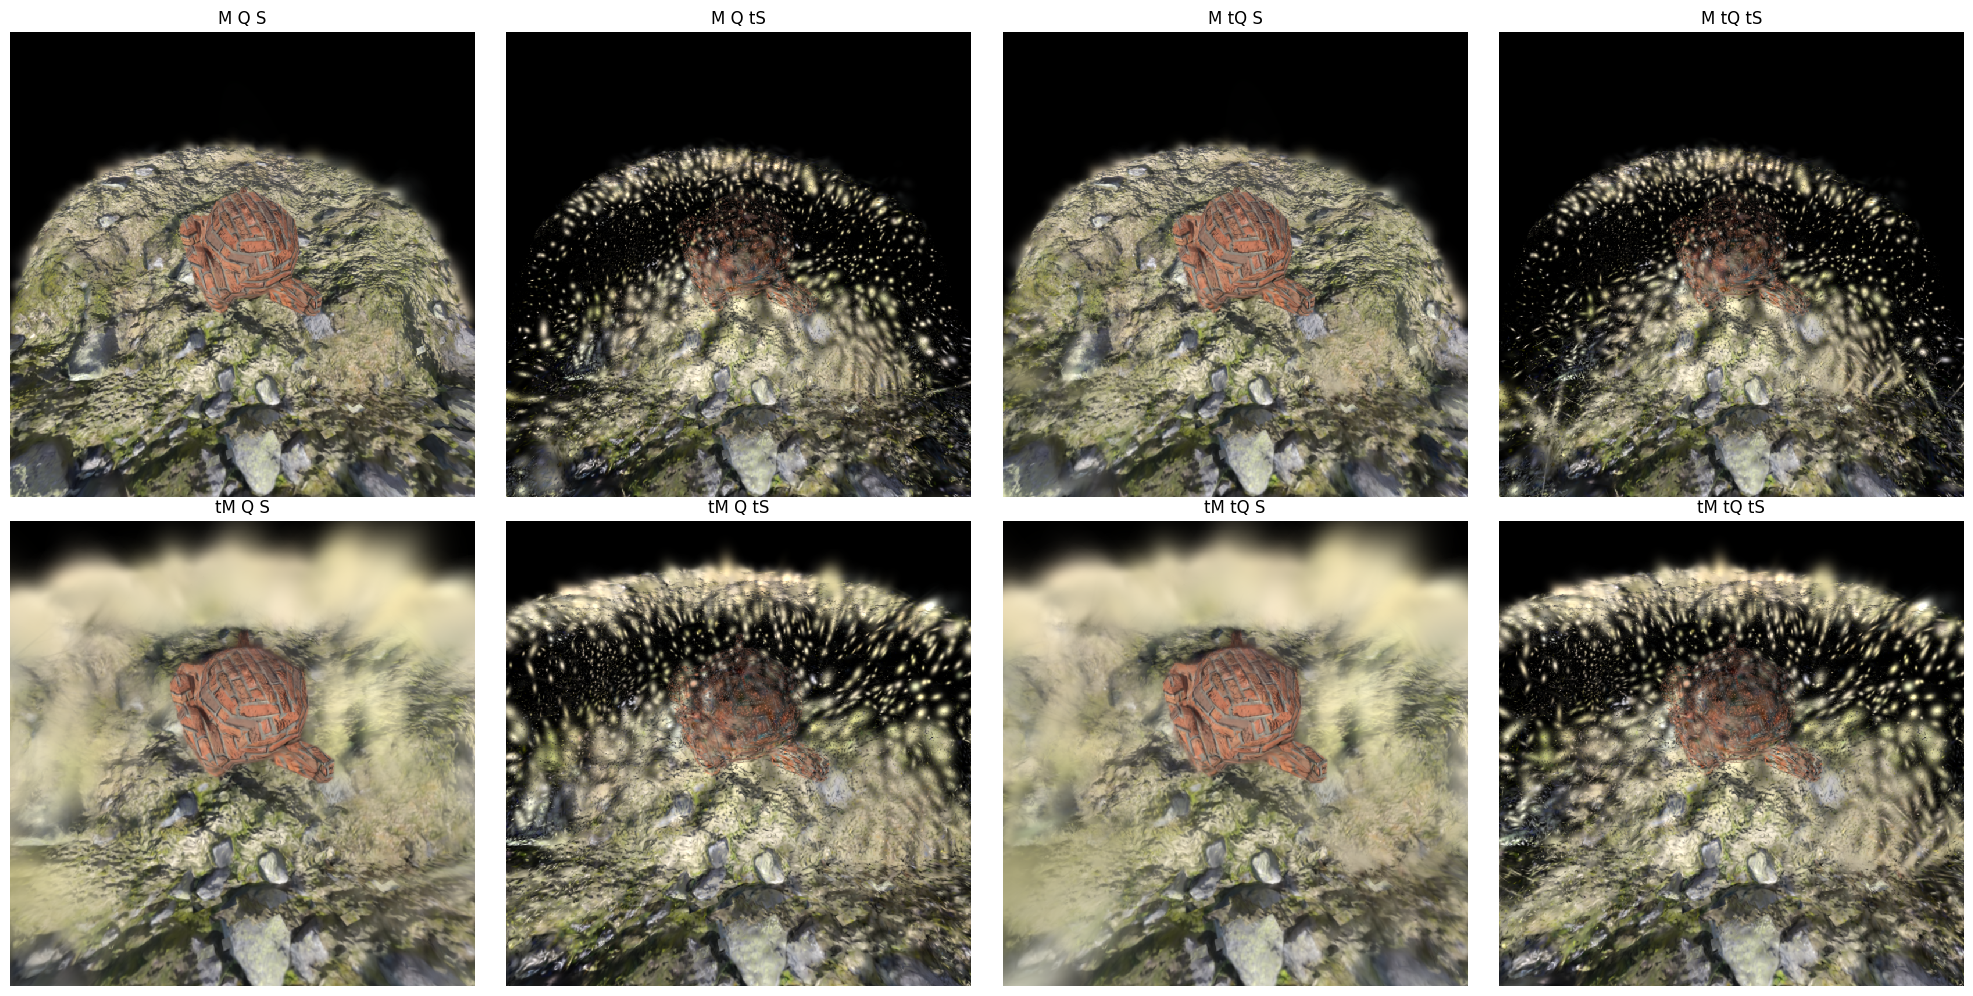

In [21]:
t_scales_by_edges = WS.scale_correction_as_real(comp_by='edges')

base_data = {
    "means": means,
    "quats": quats,
    "scales": scales,
}
transformed_data = {
    "means": t_means,
    "quats": t_quats,
    "scales": t_scales_by_edges,
}


compare_rasterization_variants(
    base_data=base_data,
    transformed_data=transformed_data,
    opacities=opacities,
    # colors=map_colors,
    colors=colors,
    worldtocam=worldtocam,
    Ks=K,
    width=width,
    height=height
)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3938662].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.379169].


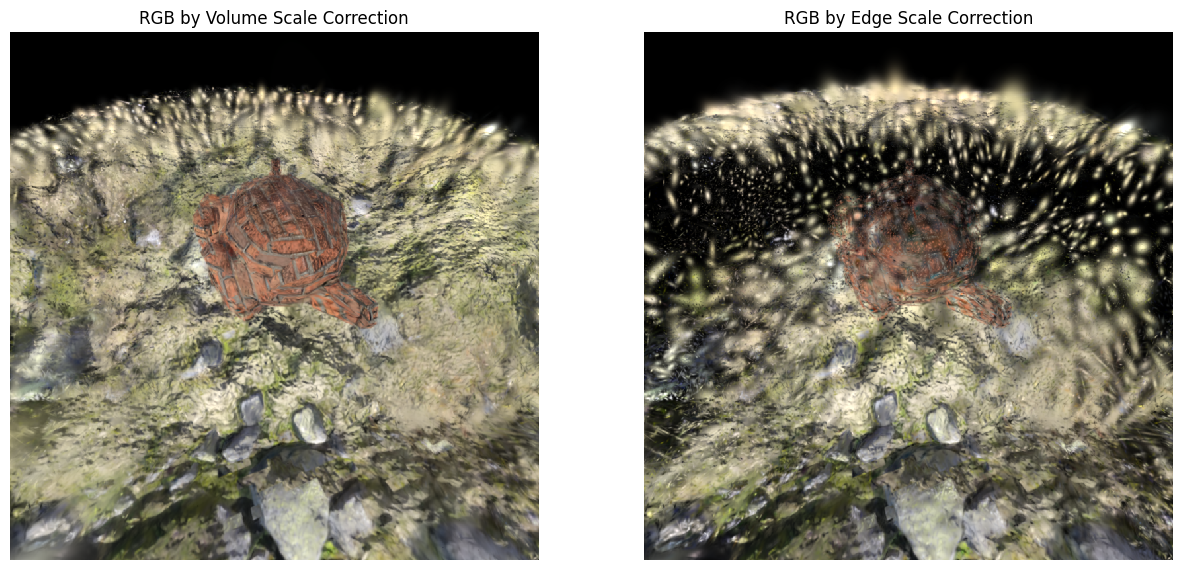

In [22]:
# compare two scale correction methods

rgb_by_volume = np_rgb_render(
    means=t_means,
    quats=t_quats,
    scales=t_scales_by_volume,
    opacities=opacities,
    colors=colors,
    worldtocam=worldtocam,
    Ks=K,
    width=width,
    height=height
)

rgb_by_edges = np_rgb_render(
    means=t_means,
    quats=t_quats,
    scales=t_scales_by_edges,
    opacities=opacities,
    colors=colors,
    worldtocam=worldtocam,
    Ks=K,
    width=width,
    height=height
)

# show the two rgb images
plt.figure(figsize=(15, 10))
plt.subplot(1, 2, 1)
plt.imshow(rgb_by_volume)
plt.title('RGB by Volume Scale Correction')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(rgb_by_edges)
plt.title('RGB by Edge Scale Correction')
plt.axis('off')
plt.show()
